논문용 [그림 3] 생성: t-SNE 기반 고차원 데이터 시각화
✓ 데이터 로드 완료.
시각화 대상 기업 ID: 75
t-SNE 분석 수행 중... (데이터 양에 따라 시간이 소요됩니다)


C:\Users\ecredible\anaconda3\envs\diceml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ecredible\anaconda3\envs\diceml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ecredible\anaconda3\envs\diceml\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



✓ [그림 3] 저장 완료: figure3_tsne_visualization.png


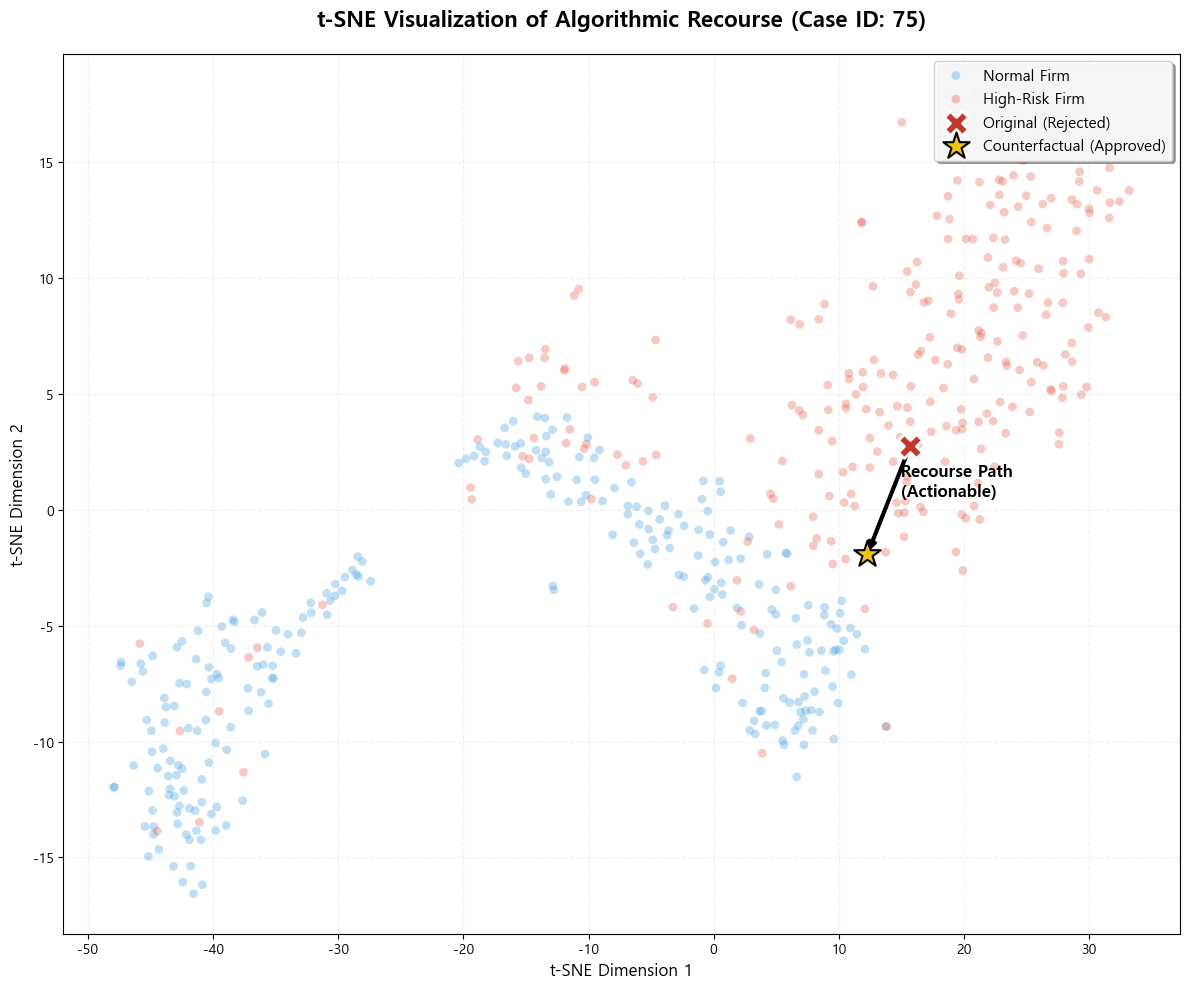

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import joblib
import os
import sys

# -------------------------------------------------------------------------
# 한글 폰트 설정
# -------------------------------------------------------------------------
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

print("=" * 80)
print("논문용 [그림 3] 생성: t-SNE 기반 고차원 데이터 시각화")
print("=" * 80)

# 1. 데이터 로드
# -------------------------------------------------------------------------
try:
    df_train = pd.read_csv('resampled_data_final.csv') # 배경 데이터
    features = joblib.load('selected_features_final.pkl')
    cf_results = pd.read_csv('cf_results_filtered.csv') # 타겟 및 CF 데이터
    print("✓ 데이터 로드 완료.")
except Exception as e:
    print(f"[Error] {e}")
    print("필수 파일이 없습니다. Step 2, 4를 먼저 실행해주세요.")
    sys.exit(1)

# 2. 시각화 대상 선정 (Case ID: 75.0)
# -------------------------------------------------------------------------
target_id = 75.0 
if target_id not in cf_results['ID'].values:
    target_id = cf_results['ID'].iloc[0]

target_row = cf_results[cf_results['ID'] == target_id].iloc[0]
print(f"시각화 대상 기업 ID: {int(target_id)}")

# 3. 데이터 전처리 (스케일링 + 데이터 병합)
# -------------------------------------------------------------------------
print("t-SNE 분석 수행 중... (데이터 양에 따라 시간이 소요됩니다)")

X = df_train[features]
y = df_train['PERF_12M']

# 스케일링 (필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 타겟 기업의 원본(Original)과 개선안(CF) 좌표 준비
original_vec = np.array([target_row[f'Original_{f}'] for f in features]).reshape(1, -1)
cf_vec = np.array([target_row[f'CF_{f}'] for f in features]).reshape(1, -1)

# 스케일링 적용
orig_scaled = scaler.transform(original_vec)
cf_scaled = scaler.transform(cf_vec)

# t-SNE는 transform 메서드가 없으므로, 전체 데이터에 타겟 데이터를 합쳐서 한 번에 학습해야 함
X_combined = np.vstack([X_scaled, orig_scaled, cf_scaled])

# 라벨 확장 (시각화용)
# 0: 정상, 1: 부도, 2: Target Original, 3: Target CF
y_combined = np.hstack([y, [2], [3]]) 

# 4. t-SNE 수행
# -------------------------------------------------------------------------
# perplexity: 이웃의 수 (보통 5~50 사이, 데이터가 적으면 낮게 설정)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_combined)

# 좌표 분리
# 배경 데이터
tsne_background = X_tsne[:-2]
# 타겟 데이터
tsne_orig = X_tsne[-2]
tsne_cf = X_tsne[-1]

# 5. 그래프 그리기
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 10))

# (1) 배경: 전체 데이터 분포
# 정상(0): 파란색 계열, 부도(1): 붉은색 계열
# alpha를 낮춰 구름처럼 표현
plt.scatter(tsne_background[y==0, 0], tsne_background[y==0, 1], 
            c='#3498db', label='Normal Firm', alpha=0.3, s=40, edgecolors='none')
plt.scatter(tsne_background[y==1, 0], tsne_background[y==1, 1], 
            c='#e74c3c', label='High-Risk Firm', alpha=0.3, s=40, edgecolors='none')

# (2) 주인공: 원본 기업 (X 마크)
plt.scatter(tsne_orig[0], tsne_orig[1], c='#c0392b', s=300, marker='X', 
            label='Original (Rejected)', zorder=10, edgecolors='white', linewidth=2)

# (3) 주인공: CF 제안 (별 마크)
plt.scatter(tsne_cf[0], tsne_cf[1], c='#f1c40f', s=400, marker='*', 
            label='Counterfactual (Approved)', zorder=10, edgecolors='black', linewidth=1.5)

# (4) 화살표: 이동 경로
plt.annotate('', xy=(tsne_cf[0], tsne_cf[1]), xytext=(tsne_orig[0], tsne_orig[1]),
             arrowprops=dict(arrowstyle='->', color='black', lw=3, ls='-'))

# (5) 텍스트 주석
mid_x = (tsne_orig[0] + tsne_cf[0]) / 2
mid_y = (tsne_orig[1] + tsne_cf[1]) / 2
plt.text(mid_x, mid_y, '  Recourse Path\n  (Actionable)', 
         fontsize=12, color='black', fontweight='bold', 
         verticalalignment='bottom')

# 스타일링
plt.title(f't-SNE Visualization of Algorithmic Recourse (Case ID: {int(target_id)})', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True, framealpha=0.9)
plt.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()

# 저장
plt.savefig('figure3_tsne_visualization.png', dpi=300, bbox_inches='tight')
print("\n✓ [그림 3] 저장 완료: figure3_tsne_visualization.png")

논문용 [그림 3] 대안: t-SNE + 결정 경계(Decision Boundary) 시각화
✓ 데이터 로드 완료.
t-SNE 학습 중... (시간 소요)


C:\Users\ecredible\anaconda3\envs\diceml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ecredible\anaconda3\envs\diceml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ecredible\anaconda3\envs\diceml\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


배경 경계 생성 중...

✓ [그림 3 대안] 저장 완료: figure3_tsne_boundary.png


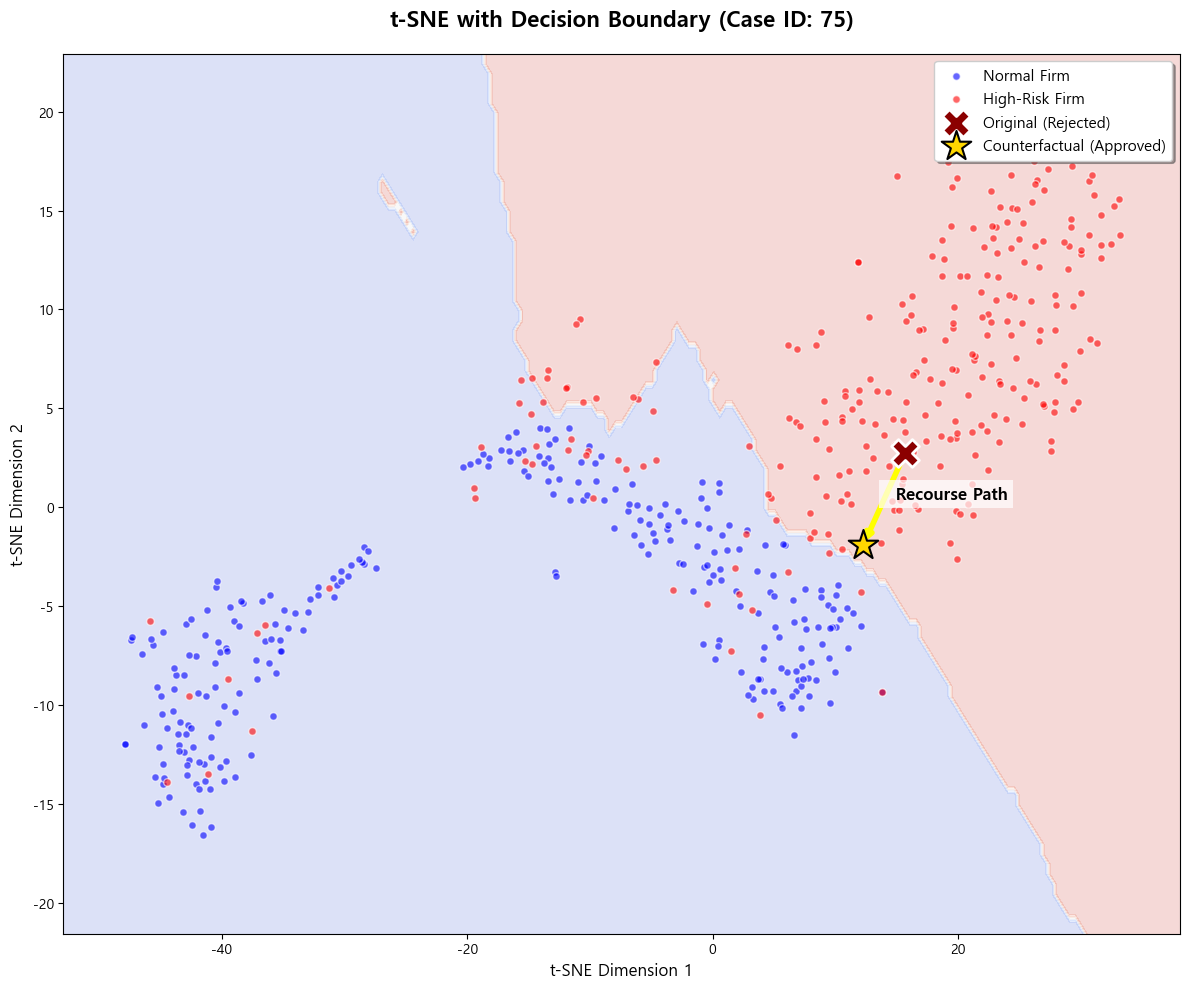

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import joblib
import os
import sys

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

print("=" * 80)
print("논문용 [그림 3] 대안: t-SNE + 결정 경계(Decision Boundary) 시각화")
print("=" * 80)

# 1. 데이터 로드
try:
    df_train = pd.read_csv('resampled_data_final.csv')
    features = joblib.load('selected_features_final.pkl')
    cf_results = pd.read_csv('cf_results_filtered.csv')
    print("✓ 데이터 로드 완료.")
except Exception as e:
    print(f"[Error] {e}")
    sys.exit(1)

# 2. 시각화 대상 선정 (ID 75.0)
target_id = 75.0 
if target_id not in cf_results['ID'].values:
    target_id = cf_results['ID'].iloc[0]

target_row = cf_results[cf_results['ID'] == target_id].iloc[0]

# 3. 데이터 전처리 (스케일링)
X = df_train[features]
y = df_train['PERF_12M']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 타겟 좌표 준비
original_vec = np.array([target_row[f'Original_{f}'] for f in features]).reshape(1, -1)
cf_vec = np.array([target_row[f'CF_{f}'] for f in features]).reshape(1, -1)

orig_scaled = scaler.transform(original_vec)
cf_scaled = scaler.transform(cf_vec)

# t-SNE 학습을 위해 전체 데이터 병합
X_combined = np.vstack([X_scaled, orig_scaled, cf_scaled])

print("t-SNE 학습 중... (시간 소요)")
# random_state 고정으로 재현성 확보
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_combined)

# 좌표 분리
X_tsne = X_embedded[:-2]
orig_tsne = X_embedded[-2]
cf_tsne = X_embedded[-1]

# 4. 결정 경계 생성을 위한 KNN 학습
# t-SNE 좌표(2D)를 입력으로 받고, 원래 클래스(y)를 예측하는 간단한 모델 학습
print("배경 경계 생성 중...")
knn = KNeighborsClassifier(n_neighbors=30) # 이웃 수를 조절하여 경계면을 부드럽게 만듦
knn.fit(X_tsne, y)

# 5. 배경 그리드 생성
x_min, x_max = X_tsne[:, 0].min() - 5, X_tsne[:, 0].max() + 5
y_min, y_max = X_tsne[:, 1].min() - 5, X_tsne[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

# 그리드 포인트에 대한 예측 (배경색 결정을 위함)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. 그래프 그리기
plt.figure(figsize=(12, 10))

# (1) 배경 결정 경계 (Contour)
# 빨강(1, 부도) vs 파랑(0, 정상) 영역 표시
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)

# (2) 산점도 (데이터 포인트)
# 가장자리 선을 넣어 더 잘 보이게 함
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], c='blue', s=30, alpha=0.6, edgecolors='white', label='Normal Firm')
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], c='red', s=30, alpha=0.6, edgecolors='white', label='High-Risk Firm')

# (3) 주인공: 이동 경로 (화살표)
plt.annotate('', xy=(cf_tsne[0], cf_tsne[1]), xytext=(orig_tsne[0], orig_tsne[1]),
             arrowprops=dict(arrowstyle='->', color='yellow', lw=4, ls='-'))

# (4) 포인트 강조
plt.scatter(orig_tsne[0], orig_tsne[1], c='darkred', s=400, marker='X', 
            label='Original (Rejected)', zorder=10, edgecolors='white', linewidth=2)

plt.scatter(cf_tsne[0], cf_tsne[1], c='gold', s=500, marker='*', 
            label='Counterfactual (Approved)', zorder=10, edgecolors='black', linewidth=1.5)

# (5) 텍스트 주석
mid_x = (orig_tsne[0] + cf_tsne[0]) / 2
mid_y = (orig_tsne[1] + cf_tsne[1]) / 2
plt.text(mid_x, mid_y, '  Recourse Path', 
         fontsize=12, color='black', fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# 스타일링
plt.title(f't-SNE with Decision Boundary (Case ID: {int(target_id)})', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(False) # 배경색이 있으므로 그리드 끔

plt.tight_layout()

# 저장
plt.savefig('figure3_tsne_boundary.png', dpi=300, bbox_inches='tight')
print("\n✓ [그림 3 대안] 저장 완료: figure3_tsne_boundary.png")